# 🩺 MedImageInsights library tutorial

In this notebook, we demonstrate the classification and embedding capabilities of MedImageInsight through the pip-installable library **MedImageInsights**.

The code can be found in this GitHub [repository](https://github.com/joortif/MedImageInsights).

This package is a streamlined packaging of the original HuggingFace repository mantained by the Lion-AI team available [here](https://huggingface.co/lion-ai/MedImageInsights). Its purpose is to make it easier to integrate MedImageInsight in Python projects by removing unecessary modules, simplifying dependencies and offering a clean `pip install` interface.

Both the original Lion-AI repo and this package are based on the work described in the paper "MedImageInsight: An Open-Source Embedding Model for General Domain Medical Imaging" by Noel C. F. Codella et al ([arXiv:2410.06542](https://arxiv.org/abs/2410.06542)). The original implementation from Lion-AI includes additional infraestructure, while **MedImageInsights** focuses exclusively on the inference interface (loading, prediction and encoding) for simplicity and ease of adoption.

Most of the implementation is inherited from the Lion-AI repository. Credit is due to Noel C. F. Codella et al., and the Lion-AI team for designing, training, and publishing the original model and code.

## 💿 MedImageInsights installation

The library is installed via pip:

In [ ]:
%pip install medimageinsights

In [23]:
import base64

import numpy as np
from PIL import Image

import os

In [24]:
def read_image_bytes(path: str) -> bytes:
  with open(path, 'rb') as f:
    return f.read()

def image_to_base64(path: str) -> str:
  return base64.encodebytes(read_image_bytes(path)).decode('utf-8')

Once the installation is done, the original MedImageInsight model can be loaded for various tasks. This model is downloaded from HuggingFace Hub.

In [25]:
from MedImageInsights.Models.medimageinsightmodel import MedImageInsight

# Initialize and load the model
classifier = MedImageInsight()
classifier.load_model()

Model loaded successfully on device: cpu


Now we load some test images. 

⚠️ Remember to download the folder `test/images` and add it to the environment if you are trying this notebook in Google Colab. You can also test the model with your own medical images.

In [26]:
phneumonia = "images/phneumonia.png"
head_ct = "images/head_ct.jpg"
breast_ultrasound = "images/breast_ultrasound.png"
melanoma = "images/melanoma.jpg"

In [27]:
mosaic_images = [phneumonia, head_ct, breast_ultrasound, melanoma]

imgs = [Image.open(p).convert("RGB") for p in mosaic_images]

size = (512, 512)
imgs = [im.resize(size) for im in imgs]

mosaic = Image.new("RGB", (size[0]*2, size[1]*2))

mosaic.paste(imgs[0], (0, 0))
mosaic.paste(imgs[1], (size[0], 0))
mosaic.paste(imgs[2], (0, size[1]))
mosaic.paste(imgs[3], (size[0], size[1]))

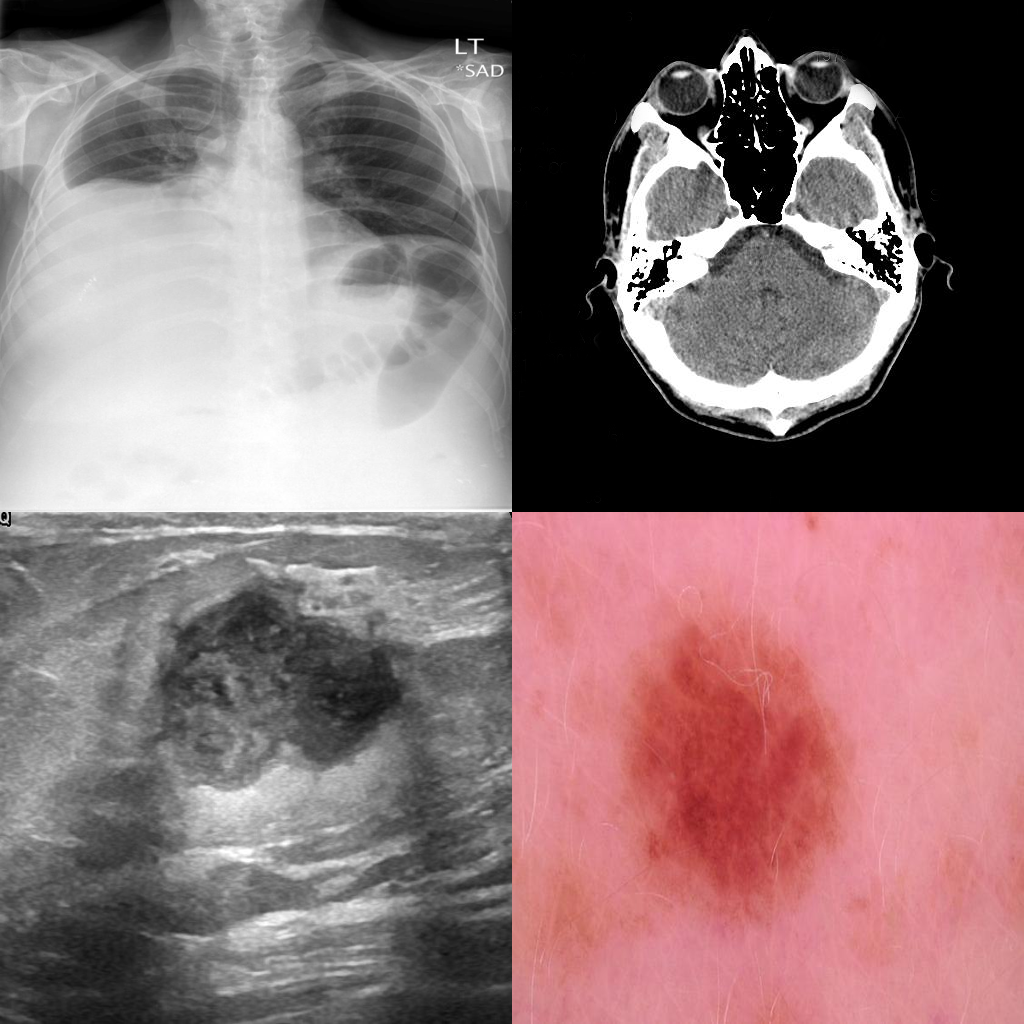

In [28]:
mosaic

## 🎯 Zero-shot classification

Images need to be converted to base64 before using `predict` and `encode`.

In [29]:
image_b64 = image_to_base64(phneumonia)
images = [image_b64] 

Before running zero-shot classification, define the labels. These are the candidate classes the model will choose from. 

In [30]:
# Example labels
labels = ['pneumonia','head CT', 'dermatology', 'breast', 'ultrasound']

In [31]:
zs_results = classifier.predict(images, labels)
print('Predict result:')
print(zs_results)

c:\Users\joortif\.pyenv\pyenv-win\versions\3.10.0\lib\site-packages\torch\utils\checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Predict result:
[{'pneumonia': 0.993669331073761, 'ultrasound': 0.004935103468596935, 'dermatology': 0.0012045417679473758, 'breast': 0.00019050294940825552, 'head CT': 6.075104010960786e-07}]


Images can also be processed in batches.

In [32]:
images_b64 = [image_to_base64(img) for img in mosaic_images]
batch_results = classifier.predict(images_b64, labels)

for img_name, result in zip(mosaic_images, batch_results):
    print(f"Prediction for {os.path.basename(img_name)}: {result}")

Prediction for phneumonia.png: {'pneumonia': 0.9982101917266846, 'ultrasound': 0.0014090294716879725, 'dermatology': 0.0002873714256566018, 'breast': 9.320690878666937e-05, 'head CT': 2.0868597516709997e-07}
Prediction for head_ct.jpg: {'head CT': 0.9826827049255371, 'dermatology': 0.01719457283616066, 'ultrasound': 7.255333912326023e-05, 'breast': 2.6949934181175195e-05, 'pneumonia': 2.331028190383222e-05}
Prediction for breast_ultrasound.png: {'ultrasound': 0.9352068305015564, 'breast': 0.053750086575746536, 'dermatology': 0.009723823517560959, 'pneumonia': 0.0013187202857807279, 'head CT': 5.15084536800714e-07}
Prediction for melanoma.jpg: {'dermatology': 0.9971152544021606, 'breast': 0.0025936122983694077, 'ultrasound': 0.0002476449008099735, 'pneumonia': 3.333810673211701e-05, 'head CT': 1.0197184565186035e-05}


## 🖼️ Image and text embeddings

The model can also be used to obtain embeddings from medical images.

In [33]:
img_emb = classifier.encode(images=images)['image_embeddings']
print('Image embedding obtained. Type/shape:', type(img_emb), np.array(img_emb).shape)
print('Image embedding:', img_emb)

Image embedding obtained. Type/shape: <class 'numpy.ndarray'> (1, 1024)
Image embedding: [[-0.01805723 -0.01677653 -0.00139412 ...  0.01299138  0.00112068
   0.0206666 ]]


In [34]:
txt_emb = classifier.encode(texts=labels)['text_embeddings']
print('Text embeddings obtained. Type/shape:', type(txt_emb), np.array(txt_emb).shape)
print('Text embedding:', txt_emb)

Text embeddings obtained. Type/shape: <class 'numpy.ndarray'> (5, 1024)
Text embedding: [[-0.00382967  0.00246505 -0.00244199 ... -0.00981619 -0.02453851
   0.03990586]
 [-0.00725215  0.02086563 -0.00685976 ...  0.01288511  0.01452657
   0.01487469]
 [-0.00691693 -0.01866071  0.00822083 ...  0.02623574  0.01041781
   0.04177827]
 [-0.02549508  0.02545661 -0.00558561 ... -0.04919488  0.02144402
   0.01046859]
 [-0.00067818  0.00324328  0.00116479 ... -0.02846618 -0.01493147
   0.01285594]]


These embeddings can be used for various tasks such as:

* **Input to ML models**: Embeddings can be used as features for anomaly detection, classifiers or other predictive models.
* **Similarity search**: In order to find the most similar images or reports to a given query.
*  **Clustering and visualization**: Group similar images or project the embeddings into a 2D or 3D space with PCA or UMAP.
* **Cross-modal search**: Compare image embeddings with text embeddings (e.g, "find chest X-rays similar to the description pneumonia").